Linear Mixed Model Analysis

In [10]:
### Set Paths for Statistical Analysis
visgam_dir  <- dirname(getwd())
results_dir <- file.path(visgam_dir, "results")
results_dir <- file.path(visgam_dir, "Results", "SNR_controls", "Revision_IN", "results_gamma")
### ----- Path to dataset ----- ###
dataset     <- file.path(results_dir, "gamma_peaks 10_10.csv")
f_band      <- "Gamma" # Alpha

### Load Packages Is
library(tidyr)
library(dplyr)

In [11]:
##### Long Format CSV
### ----- Read Dataset 
df      <- read.csv(dataset)

### ----- Transform to Long Format
df_long <- df %>%
  pivot_longer(
    cols = c(pf_opm, pf_eeg, pp_opm, pp_eeg),
    names_to = c("Measure", "Modality"),
    names_pattern = "^([^_]+)_([^_]+)(?:_.+)?$",
    values_to = "Value"
  ) %>%
  mutate(
    Measure = dplyr::recode(
      Measure,
      "pf" = paste0("Peak_Freq_", f_band),
      "pp" = paste0("Peak_Power_", f_band)
    ),
    Modality = dplyr::recode(
      Modality,
      "opm" = "OPM",
      "eeg" = "EEG"
    ),
    SZ_EEG_INFO = factor(
      SZ_EEG_INFO,
      levels = c(0, 1),
      labels = c("Control", "Patient")
    )
  )

df_model <- df_long %>%
  filter(Measure == paste0("Peak_Power_", f_band)) %>%
  mutate(
    Modality = factor(Modality),
    SZ_EEG_INFO = factor(SZ_EEG_INFO)
  )

In [12]:
### Load Packages for Statistical Analysis
library(lme4)
library(MuMIn)
library(lmerTest)
library(car)
library(performance)
#https://stat.ethz.ch/~meier/teaching/anova/random-and-mixed-effects-models.html#mixed-effects-models
library(effectsize)
library(emmeans)

[1] "numeric"

SZ_EEG_INFO,mean,sd,median,n
<fct>,<dbl>,<dbl>,<dbl>,<int>
Control,189.4231,25.41523,196.5,26
Patient,187.2609,19.46843,192.0,23



	Welch Two Sample t-test

data:  CommonTrials by SZ_EEG_INFO
t = 0.33636, df = 46.111, p-value = 0.7381
alternative hypothesis: true difference in means between group Control and group Patient is not equal to 0
95 percent confidence interval:
 -10.77640  15.10082
sample estimates:
mean in group Control mean in group Patient 
             189.4231              187.2609 


Warning message in wilcox.test.default(x = DATA[[1L]], y = DATA[[2L]], ...):
"cannot compute exact p-value with ties"



	Wilcoxon rank sum test with continuity correction

data:  CommonTrials by SZ_EEG_INFO
W = 338.5, p-value = 0.4343
alternative hypothesis: true location shift is not equal to 0


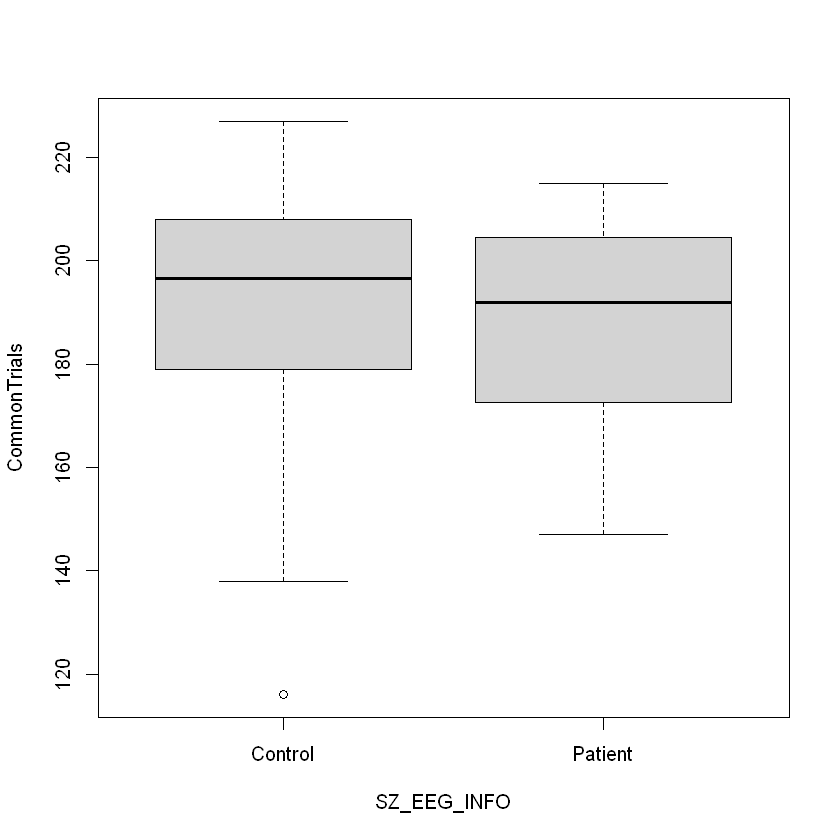

In [13]:
class(df_model$CommonTrials)   # confirm it's "factor"

### Convert properly -- always go through as.character() first,
### otherwise you get the factor's internal level numbers, not the
### actual values
df_trials <- df_model |>
  distinct(DatasetID, SZ_EEG_INFO, CommonTrials) |>
  mutate(CommonTrials = as.numeric(as.character(CommonTrials)))

df_trials |>
  group_by(SZ_EEG_INFO) |>
  summarise(mean = mean(CommonTrials), sd = sd(CommonTrials),
            median = median(CommonTrials), n = n())

t.test(CommonTrials ~ SZ_EEG_INFO, data = df_trials)
wilcox.test(CommonTrials ~ SZ_EEG_INFO, data = df_trials)
boxplot(CommonTrials ~ SZ_EEG_INFO, data = df_trials)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value ~ Modality * SZ_EEG_INFO + (1 | DatasetID)
   Data: df_model

REML criterion at convergence: 374.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.23962 -0.53154 -0.04307  0.38386  2.98020 

Random effects:
 Groups    Name        Variance Std.Dev.
 DatasetID (Intercept) 2.747    1.658   
 Residual              1.138    1.067   
Number of obs: 98, groups:  DatasetID, 49

Fixed effects:
                               Estimate Std. Error       df t value Pr(>|t|)
(Intercept)                     1.96048    0.38656 62.66309   5.072 3.76e-06
ModalityOPM                     1.12567    0.29583 47.00000   3.805 0.000409
SZ_EEG_INFOPatient             -0.92556    0.56422 62.66309  -1.640 0.105929
ModalityOPM:SZ_EEG_INFOPatient -0.06869    0.43179 47.00000  -0.159 0.874287
                                  
(Intercept)                    ***
ModalityOPM                    ***


[1] "Fixed effects analysis"
Type II Analysis of Variance Table with Satterthwaite's method
                      Sum Sq Mean Sq NumDF DenDF F value    Pr(>F)    
Modality             29.2916 29.2916     1    47 25.7463 6.545e-06 ***
SZ_EEG_INFO           3.8578  3.8578     1    47  3.3909   0.07187 .  
Modality:SZ_EEG_INFO  0.0288  0.0288     1    47  0.0253   0.87429    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


[1] 0.354 0.067 0.001

[1] 0.147 0.000 0.000

[1] 0.529 0.238 0.065

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Modality,29.292,29.292,1,47,25.746,0.000
SZ_EEG_INFO,3.858,3.858,1,47,3.391,0.072
Modality:SZ_EEG_INFO,0.029,0.029,1,47,0.025,0.874



	Shapiro-Wilk normality test

data:  resid(model_raw)
W = 0.94643, p-value = 0.0005624


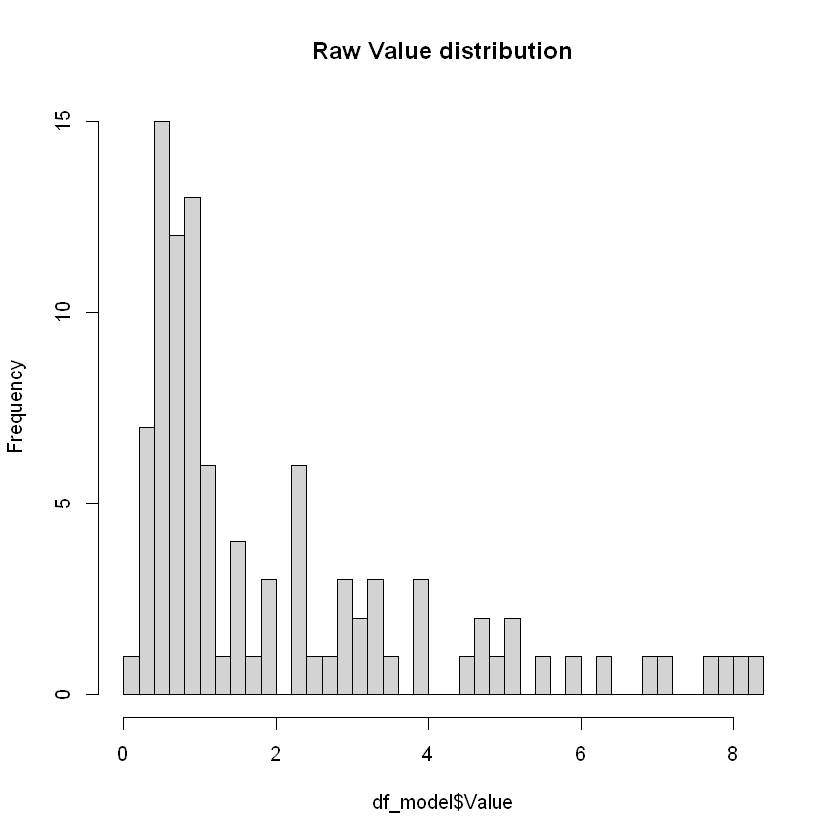

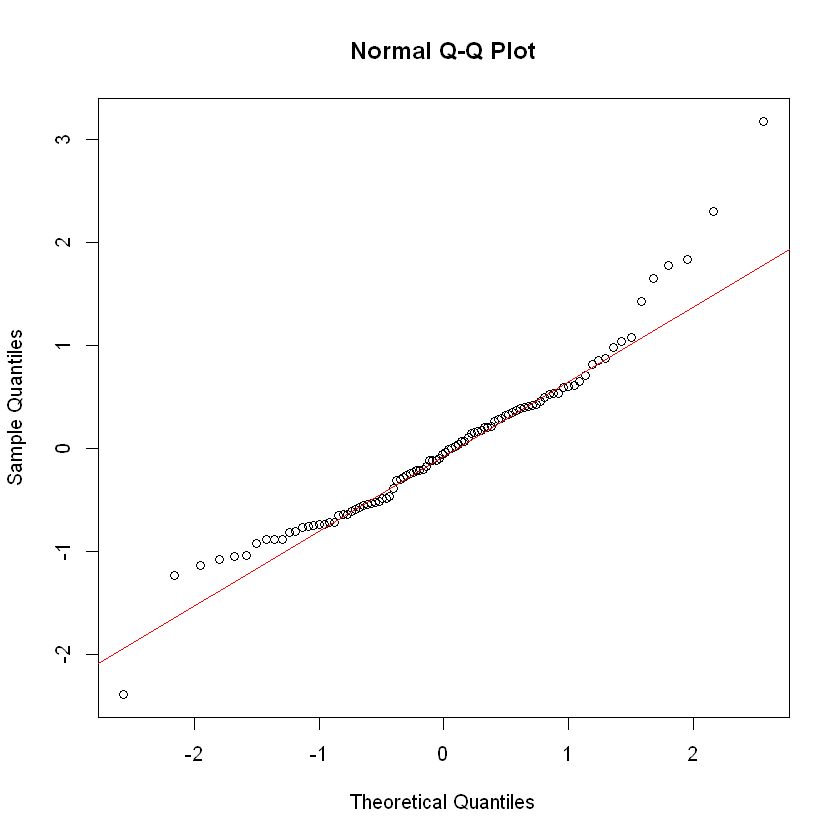

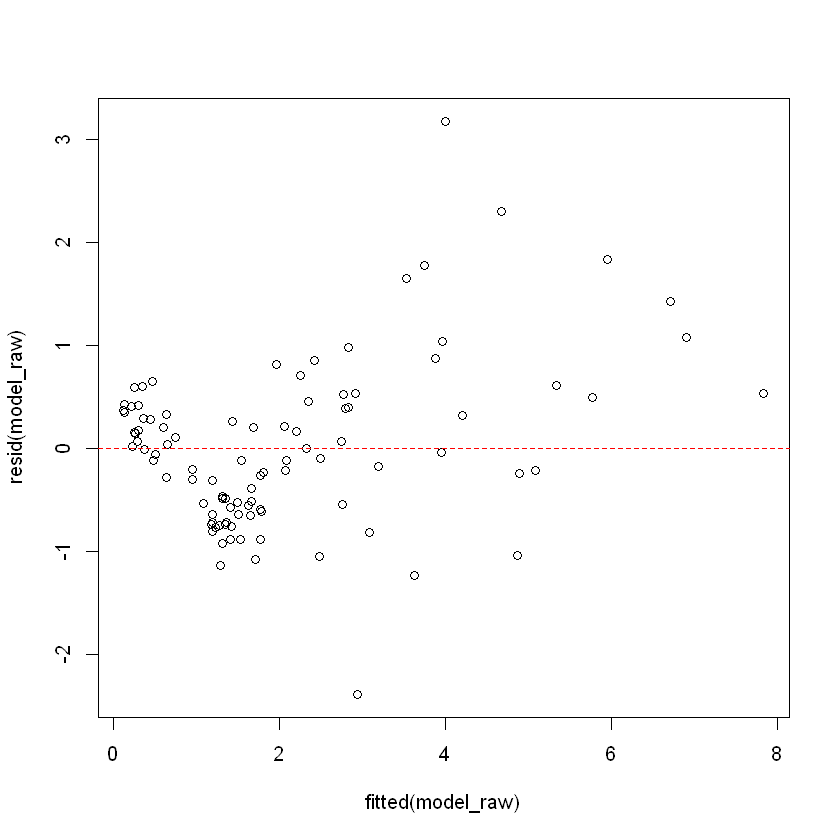

In [14]:

### Visualize
hist(df_model$Value, breaks = 40, main = "Raw Value distribution")

### Fit the raw pooled model (with interaction) and check its residuals
model_raw <- lmer(
  Value ~ Modality * SZ_EEG_INFO + (1 | DatasetID),
  data = df_model
)
### Print Summary
ampsum    <- summary(model_raw)
model_amp <- as.data.frame(round(ampsum$coefficients, 3))
ampsum

### Print Analysis of Fixed Effects
print("Fixed effects analysis")
aovamp <- anova(model_raw, type="II", test="F")
print(aovamp)
eff   <- eta_squared(aovamp, alternative="two.sided")
round(eff$Eta2_partial, 3)
round(eff$CI_low, 3)
round(eff$CI_high, 3)

aovamp <- round(as.data.frame(aovamp), 3)
aovamp

shapiro.test(resid(model_raw))
qqnorm(resid(model_raw)); qqline(resid(model_raw), col = "red")
plot(fitted(model_raw), resid(model_raw)); abline(h = 0, lty = 2, col = "red")

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1667  0.6355  1.0423  2.0727  2.9313  8.3750 

[1] 0


	Shapiro-Wilk normality test

data:  resid(model_rank)
W = 0.99149, p-value = 0.7938


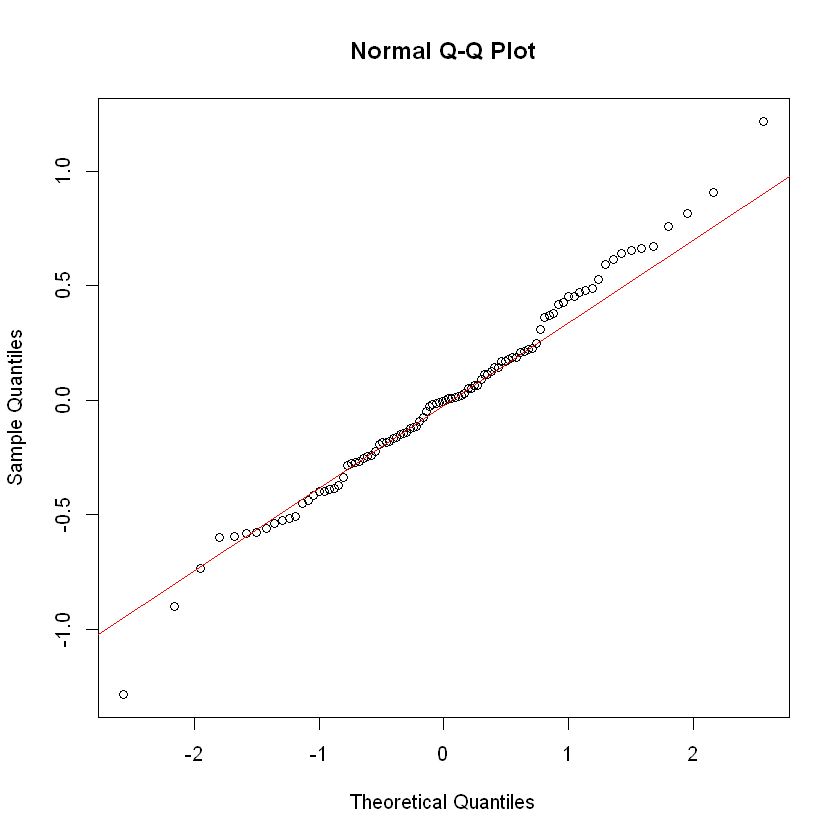

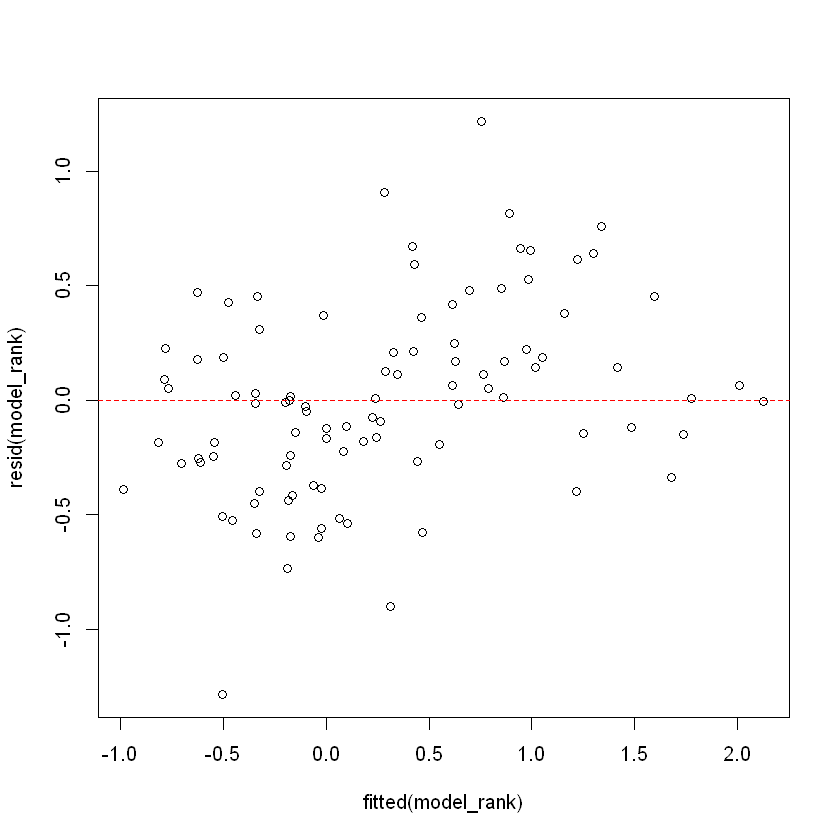

In [6]:
summary(df_model$Value)
sum(df_model$Value <= 0, na.rm = TRUE)

df_model$Value_rank <- log(df_model$Value)

model_rank <- lmer(
  Value_rank ~ Modality * SZ_EEG_INFO + (1 | DatasetID),
  data = df_model
)

shapiro.test(resid(model_rank))
qqnorm(resid(model_rank)); qqline(resid(model_rank), col = "red")
plot(fitted(model_rank), resid(model_rank)); abline(h = 0, lty = 2, col = "red")


In [7]:
### Print Summary
ampsum    <- summary(model_rank)
model_amp <- as.data.frame(round(ampsum$coefficients, 3))
ampsum

### Print Analysis of Fixed Effects
print("Fixed effects analysis")
aovamp <- anova(model_rank, type="II", test="F")
print(aovamp)
eff   <- eta_squared(aovamp, alternative="two.sided")
round(eff$Eta2_partial, 3)
round(eff$CI_low, 3)
round(eff$CI_high, 3)

aovamp <- round(as.data.frame(aovamp), 3)
aovamp

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value_rank ~ Modality * SZ_EEG_INFO + (1 | DatasetID)
   Data: df_model

REML criterion at convergence: 231.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.38511 -0.49212 -0.00504  0.41039  2.25951 

Random effects:
 Groups    Name        Variance Std.Dev.
 DatasetID (Intercept) 0.4726   0.6875  
 Residual              0.2908   0.5393  
Number of obs: 98, groups:  DatasetID, 49

Fixed effects:
                               Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)                      0.1135     0.1714 67.9560   0.662    0.510    
ModalityOPM                      0.7891     0.1496 47.0000   5.276 3.29e-06 ***
SZ_EEG_INFOPatient              -0.3138     0.2501 67.9560  -1.255    0.214    
ModalityOPM:SZ_EEG_INFOPatient  -0.3485     0.2183 47.0000  -1.597    0.117    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fi

[1] "Fixed effects analysis"
Type II Analysis of Variance Table with Satterthwaite's method
                     Sum Sq Mean Sq NumDF DenDF F value    Pr(>F)    
Modality             9.5869  9.5869     1    47 32.9671 6.607e-07 ***
SZ_EEG_INFO          1.3681  1.3681     1    47  4.7047   0.03517 *  
Modality:SZ_EEG_INFO 0.7413  0.7413     1    47  2.5492   0.11705    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


[1] 0.412 0.091 0.051

[1] 0.201 0.000 0.000

[1] 0.576 0.270 0.214

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Modality,9.587,9.587,1,47,32.967,0.000
SZ_EEG_INFO,1.368,1.368,1,47,4.705,0.035
Modality:SZ_EEG_INFO,0.741,0.741,1,47,2.549,0.117


Warning message:
"package 'influence.ME' was built under R version 4.5.3"

Attaching package: 'influence.ME'


The following object is masked from 'package:stats':

    influence




[1] "msa20" "mto27" "shs24" "ukc06"

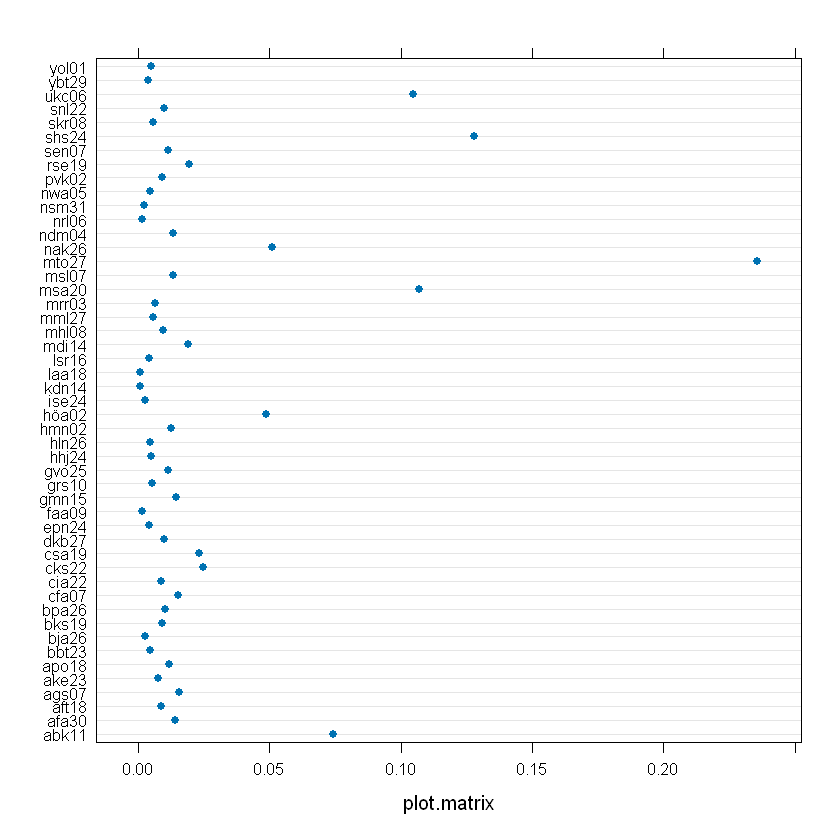

In [8]:
library(influence.ME)

infl    <- influence(model_raw, group = "DatasetID")
cooks_d <- cooks.distance(infl)

### Common rule-of-thumb cutoff for flagging influential subjects
cutoff <- 4 / length(cooks_d)
high_infl <- rownames(cooks_d)[cooks_d > cutoff]
high_infl

plot(infl, which = "cook")

In [9]:
df_model_sensitivity <- df_model |> filter(!DatasetID %in% high_infl)

model_sens <- lmer(
  Value ~ Modality * SZ_EEG_INFO + (1 | DatasetID),
  data = df_model_sensitivity
)
round(anova(model_sens, type = "II"), 3)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Modality,16.895,16.895,1,43,27.932,0.000
SZ_EEG_INFO,5.523,5.523,1,43,9.130,0.004
Modality:SZ_EEG_INFO,2.448,2.448,1,43,4.046,0.051


In [5]:
############################################
### Aligned Rank Transform (ART) Analysis ###
### Robustness / diagnostic check for the ###
### Modality x SZ_EEG_INFO interaction    ###
############################################

# install.packages("ARTool")   # run once if not already installed
library(ARTool)
library(effectsize)

### Make sure factors are coded correctly --
### art() requires fixed-effect predictors to be factors, not
### character/numeric, or alignment will fail or misbehave
df_model$Modality    <- as.factor(df_model$Modality)
df_model$SZ_EEG_INFO <- as.factor(df_model$SZ_EEG_INFO)
#df_model$CommonTrials <- as.factor(df_model$CommonTrials)

### Fit the ART model -- same fixed/random structure as your lmer
### models. The (1 | DatasetID) random effect is retained inside each
### of the per-term aligned models ART fits internally.
model_art <- art(
  Value ~ Modality*SZ_EEG_INFO + (1 | DatasetID),
  data = df_model
)

### Check alignment worked correctly. Look at the "F values" table --
### the column sums of aligned responses should all be ~0. Also check
### for any lmer convergence warnings printed for the individual
### per-term models.
print(model_art)

### Fixed effects analysis -- nonparametric F-tests per term
print("Fixed effects analysis (ART)")
aovart <- anova(model_art, type="II", test="F")
print(aovart)

### Effect sizes (partial eta-squared computed from ART's F-statistics)
eff <- F_to_eta2(
  f        = aovart$`F`,
  df       = aovart$Df,
  df_error = aovart$`Df.res`
)
round(eff$Eta2_partial, 3)
round(eff$CI_low, 3)
round(eff$CI_high, 3)

aovart_df <- as.data.frame(aovart)
aovart_df[sapply(aovart_df, is.numeric)] <- round(aovart_df[sapply(aovart_df, is.numeric)], 3)
aovart_df

### -------------------------------------------------------------
### OPTIONAL: post-hoc contrasts, only if the interaction is
### significant. Always use ART's own contrast function -- not
### emmeans directly on model_art -- since art.con() correctly
### follows up on the aligned-rank data rather than the raw scale.
### -------------------------------------------------------------
# art.con(model_art, "Modality:SZ_EEG_INFO", adjust = "holm")

Warning message:
"package 'ARTool' was built under R version 4.5.3"
Warning message in summary.art(x):
"F values of ANOVAs on aligned responses not of interest are not all ~0. ART may not be appropriate."


Aligned Rank Transform of Factorial Model

Call:
art(formula = Value ~ Modality * SZ_EEG_INFO + (1 | DatasetID), 
    data = df_model)

Column sums of aligned responses (should all be ~0):
            Modality          SZ_EEG_INFO Modality:SZ_EEG_INFO 
                   0                    0                    0 

F values of ANOVAs on aligned responses not of interest (should all be ~0):
     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.000e+00 0.000e+00 0.000e+00 1.581e-05 0.000e+00 9.486e-05 
[1] "Fixed effects analysis (ART)"
Analysis of Variance of Aligned Rank Transformed Data

Table Type: Analysis of Deviance Table (Type II Wald F tests with Kenward-Roger df) 
Model: Mixed Effects (lmer)
Response: art(Value)

                             F Df Df.res     Pr(>F)    
1 Modality             32.6907  1     47 7.1836e-07 ***
2 SZ_EEG_INFO           6.0665  1     47  0.0174958   *
3 Modality:SZ_EEG_INFO 10.0577  1     47  0.0026717  **
---
Signif. codes:   0 '***' 0.001 

[1] 0.410 0.114 0.176

[1] 0.233 0.012 0.041

[1] 1 1 1

,Term,F,Df,Df.res,Pr(>F)
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Modality,Modality,32.691,1,47,0.000
SZ_EEG_INFO,SZ_EEG_INFO,6.066,1,47,0.017
Modality:SZ_EEG_INFO,Modality:SZ_EEG_INFO,10.058,1,47,0.003


In [13]:
art.con(model_art, "Modality:SZ_EEG_INFO", adjust="holm")

 contrast                  estimate   SE   df t.ratio p.value
 EEG,Control - EEG,Patient     9.49 7.42 71.1   1.280  0.4091
 EEG,Control - OPM,Control   -24.38 4.72 47.0  -5.162  <.0001
 EEG,Control - OPM,Patient    -3.07 7.42 71.1  -0.414  0.6801
 EEG,Patient - OPM,Control   -33.88 7.42 71.1  -4.569  0.0001
 EEG,Patient - OPM,Patient   -12.57 5.02 47.0  -2.502  0.0477
 OPM,Control - OPM,Patient    21.31 7.42 71.1   2.874  0.0214

Degrees-of-freedom method: kenward-roger 
P value adjustment: holm method for 6 tests 

In [11]:
raw_contrasts <- art.con(model_art, "Modality:SZ_EEG_INFO", adjust = "none")
raw_df <- as.data.frame(raw_contrasts)
raw_df   # confirm exact contrast label strings before filtering

meaningful_labels <- c(
  "EEG,Control - EEG,Patient",   # Group | EEG
  "OPM,Control - OPM,Patient",   # Group | OPM
  "EEG,Control - OPM,Control",   # Modality | Control
  "EEG,Patient - OPM,Patient"    # Modality | Patient
)

target_rows <- raw_df[raw_df$contrast %in% meaningful_labels, ]
target_rows$p_holm <- p.adjust(target_rows$p.value, method = "holm")
target_rows
round(target_rows$p_holm, 3)

,contrast,estimate,SE,df,t.ratio,p.value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,"EEG,Control - EEG,Patient",9.494983,7.415707,71.08664,1.2803881,2.045709e-01
2,"EEG,Control - OPM,Control",-24.384615,4.723951,47.00000,-5.1619107,4.855783e-06
3,"EEG,Control - OPM,Patient",-3.070234,7.415707,71.08664,-0.4140177,6.801077e-01
4,"EEG,Patient - OPM,Control",-33.879599,7.415707,71.08664,-4.5686268,2.014777e-05
5,"EEG,Patient - OPM,Patient",-12.565217,5.022595,47.00000,-2.5017380,1.589808e-02
6,"OPM,Control - OPM,Patient",21.314381,7.415707,71.08664,2.8742210,5.338422e-03


,contrast,estimate,SE,df,t.ratio,p.value,p_holm
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,"EEG,Control - EEG,Patient",9.494983,7.415707,71.08664,1.280388,2.045709e-01,2.045709e-01
2,"EEG,Control - OPM,Control",-24.384615,4.723951,47.00000,-5.161911,4.855783e-06,1.942313e-05
5,"EEG,Patient - OPM,Patient",-12.565217,5.022595,47.00000,-2.501738,1.589808e-02,3.179616e-02
6,"OPM,Control - OPM,Patient",21.314381,7.415707,71.08664,2.874221,5.338422e-03,1.601527e-02


[1] 0.205 0.000 0.032 0.016

In [21]:
library(dplyr)
library(tidyr)
library(effectsize)

df_agg <- df_model |>
  group_by(DatasetID, Modality, SZ_EEG_INFO) |>
  summarise(Value = mean(Value, na.rm = TRUE), .groups = "drop")

### --- Modality within Control (paired: same subjects, EEG vs OPM) ---
w_ctrl <- df_agg |> filter(SZ_EEG_INFO == "Control") |>
  pivot_wider(names_from = Modality, values_from = Value)
D <- w_ctrl$OPM - w_ctrl$EEG
dz_ctrl <- mean(D) / sd(D)
g_ctrl  <- dz_ctrl * (1 - 3/(4*length(D) - 9))
rb_ctrl <- rank_biserial(w_ctrl$OPM, w_ctrl$EEG, paired = TRUE)

### --- Modality within Patient (paired) ---
w_pat <- df_agg |> filter(SZ_EEG_INFO == "Patient") |>
  pivot_wider(names_from = Modality, values_from = Value)
D2 <- w_pat$OPM - w_pat$EEG
dz_pat <- mean(D2) / sd(D2)
g_pat  <- dz_pat * (1 - 3/(4*length(D2) - 9))
rb_pat <- rank_biserial(w_pat$OPM, w_pat$EEG, paired = TRUE)

### --- Group within EEG (independent: Control vs Patient) ---
df_eeg <- df_agg |> filter(Modality == "EEG")
x1 <- df_eeg$Value[df_eeg$SZ_EEG_INFO == "Control"]
x2 <- df_eeg$Value[df_eeg$SZ_EEG_INFO == "Patient"]
sd_p <- sqrt(((length(x1)-1)*sd(x1)^2 + (length(x2)-1)*sd(x2)^2) / (length(x1)+length(x2)-2))
d_eeg <- (mean(x1) - mean(x2)) / sd_p
g_eeg <- d_eeg * (1 - 3/(4*(length(x1)+length(x2)) - 9))
rb_eeg <- rank_biserial(x1, x2)

### --- Group within OPM (independent) ---
df_opm <- df_agg |> filter(Modality == "OPM")
x3 <- df_opm$Value[df_opm$SZ_EEG_INFO == "Control"]
x4 <- df_opm$Value[df_opm$SZ_EEG_INFO == "Patient"]
sd_p2 <- sqrt(((length(x3)-1)*sd(x3)^2 + (length(x4)-1)*sd(x4)^2) / (length(x3)+length(x4)-2))
d_opm <- (mean(x3) - mean(x4)) / sd_p2
g_opm <- d_opm * (1 - 3/(4*(length(x3)+length(x4)) - 9))
rb_opm <- rank_biserial(x3, x4)

### Summary
data.frame(
  contrast = c("Modality | Control", "Modality | Patient", "Group | EEG", "Group | OPM"),
  cohen_dz = round(c(dz_ctrl, dz_pat, d_eeg, d_opm) * c(1,1,1,1), 3),  # g already corrected for first two
  rank_biserial_r = round(c(rb_ctrl$r_rank_biserial, rb_pat$r_rank_biserial,
                             rb_eeg$r_rank_biserial, rb_opm$r_rank_biserial), 3)
)

contrast,cohen_dz,rank_biserial_r
<chr>,<dbl>,<dbl>
Modality | Control,0.974,0.840
Modality | Patient,0.578,0.630
Group | EEG,0.539,0.147
Group | OPM,0.453,0.441


In [7]:
#####################################################
### Inverse Normal Transformation (INT) Analysis  ###
### Robustness check for the ART result, following ###
### the critique that ART fails to control Type I  ###
### error under skewed / unequal-variance data      ###
### (statransform.github.io/jovi preprint)          ###
#####################################################

# INT is the alternative these authors recommend in place of ART.
# It's a much simpler, single global transform (rank the raw data,
# then push those ranks through the standard-normal quantile function)
# -- unlike ART, there's no per-effect alignment step, so a standard
# lmer() on the transformed outcome is all that's needed.

library(lme4)
library(car)         # Anova() for Type III F-tests on the mixed model
library(emmeans)      # follow-up contrasts, mirrors your ART workflow
library(effectsize)   # F_to_eta2, for direct comparison with the ART result

### -------------------------------------------------------------
### Step 1: Inverse normal transform of the raw outcome
### -------------------------------------------------------------
### Blom's formula (the most common INT variant, and the one used
### in most of the papers comparing INT to ART/rank methods):
###   INT(x_i) = qnorm( (rank(x_i) - 3/8) / (n + 1/4) )
### Ties are broken with average ranks (R's default for rank()).

inverse_normal_transform <- function(x) {
  r <- rank(x, na.last = "keep", ties.method = "average")
  n <- sum(!is.na(x))
  qnorm((r - 3/8) / (n + 1/4))
}

df_model$Value_INT <- inverse_normal_transform(df_model$Value)

### Sanity check: the transformed variable should now look
### essentially normal (this is the whole point of INT) --
### confirm before trusting the model p-values.
print(shapiro.test(df_model$Value_INT))

### Make sure factors are coded correctly, same requirement as art()
df_model$Modality    <- as.factor(df_model$Modality)
df_model$SZ_EEG_INFO <- as.factor(df_model$SZ_EEG_INFO)

### -------------------------------------------------------------
### Step 2: Fit an ordinary lmer on the transformed outcome --
### same fixed/random structure as your finalized ART model
### (Value ~ Modality * SZ_EEG_INFO + (1 | DatasetID))
### -------------------------------------------------------------
model_int <- lmer(
  Value_INT ~ Modality * SZ_EEG_INFO + (1 | DatasetID),
  data = df_model
)

print(summary(model_int))

### Residual diagnostics on the transformed model -- INT should
### have fixed the normality problem that motivated moving away
### from the raw-scale lmer in the first place. If this still
### fails, that's useful to know too.
print(shapiro.test(residuals(model_int)))

### -------------------------------------------------------------
### Step 3: Fixed effects -- Type III F-test on the interaction
### -------------------------------------------------------------
print("Fixed effects analysis (INT + lmer)")
aovint <- Anova(model_int, type = 3, test.statistic = "F")
print(aovint)

### Effect size (partial eta-squared), computed the same way as
### for the ART result so the two are directly comparable
eff_int <- F_to_eta2(
  f        = aovint$`F`,
  df       = aovint$Df,
  df_error = aovint$Df.res
)
round(eff_int$Eta2_partial, 3)
round(eff_int$CI_low, 3)
round(eff_int$CI_high, 3)

aovint_rounded <- round(as.data.frame(aovint), 3)
aovint_rounded

### -------------------------------------------------------------
### Step 4: Compare against the logged ART result
### -------------------------------------------------------------
### Your ART result (art_analysis.R, omnibus interaction):
###   F(1,47) = 12.74, p < .001, partial eta^2 = .213
### If model_int's interaction F/p/eta^2 land in the same
### ballpark and same direction, that's convergent evidence the
### interaction isn't an ART artifact. If they diverge sharply,
### that's exactly the kind of discrepancy worth reporting.
cat(sprintf(
  "\nART   (logged): F(1,47) = 12.74, p < .001, partial eta^2 = .213\n"
))
cat(sprintf(
  "INT (this run): F(%.0f,%.1f) = %.2f, p = %.4g, partial eta^2 = %.3f\n",
  aovint["Modality:SZ_EEG_INFO", "Df"],
  aovint["Modality:SZ_EEG_INFO", "Df.res"],
  aovint["Modality:SZ_EEG_INFO", "F"],
  aovint["Modality:SZ_EEG_INFO", "Pr(>F)"],
  eff_int$Eta2_partial[rownames(aovint) == "Modality:SZ_EEG_INFO"]
))

### -------------------------------------------------------------
### Step 5 (OPTIONAL): follow-up contrasts, same 4-contrast
### planned family as your final ART results (section 5 of the
### stats log), so the two methods can be compared contrast by
### contrast, not just on the omnibus interaction.
###
### IMPORTANT: this deliberately uses emmeans' own simple-effects
### machinery (pairs() on a `~ A | B` grid) rather than hand-built
### 0/1/-1 contrast vectors. An earlier version of this script used
### hardcoded vectors that assumed a specific row order from
### emmeans(~ Modality * SZ_EEG_INFO) -- that assumption was wrong
### (emmeans actually orders rows (EEG,Ctrl), (OPM,Ctrl), (EEG,Patient),
### (OPM,Patient), not interleaved by Modality first), which silently
### attached correct estimates to the WRONG labels. Verified against
### synthetic test data before catching it. Letting emmeans label its
### own contrasts removes that entire bug class.
### -------------------------------------------------------------
emm_int <- emmeans(model_int, ~ Modality * SZ_EEG_INFO)
print(emm_int)

### Simple effect of Group, within each Modality
grp_within_modality <- emmeans(model_int, ~ SZ_EEG_INFO | Modality)
grp_pairs <- pairs(grp_within_modality)
print(grp_pairs)

### Simple effect of Modality, within each Group
mod_within_group <- emmeans(model_int, ~ Modality | SZ_EEG_INFO)
mod_pairs <- pairs(mod_within_group)
print(mod_pairs)

### Combine into the same 4-contrast planned family used for the
### ART follow-ups, and Holm-correct across just this family (not
### every contrast emmeans could produce) -- same logic as section 6
### of your stats log.
### grp_pairs and mod_pairs have DIFFERENT grouping columns (Modality
### vs SZ_EEG_INFO respectively -- each is whatever was held fixed),
### so a plain rbind() on the raw objects won't align columns. Collapse
### each one's "what was held fixed" info into a single label column
### first.
grp_df <- as.data.frame(grp_pairs)
grp_df$fixed_at <- paste0("Modality = ", grp_df$Modality)

mod_df <- as.data.frame(mod_pairs)
mod_df$fixed_at <- paste0("SZ_EEG_INFO = ", mod_df$SZ_EEG_INFO)

keep_cols <- c("contrast", "fixed_at", "estimate", "SE", "df", "t.ratio", "p.value")
combined <- rbind(grp_df[, keep_cols], mod_df[, keep_cols])
combined$p.holm <- p.adjust(combined$p.value, method = "holm")
print(combined)


	Shapiro-Wilk normality test

data:  df_model$Value_INT
W = 0.99913, p-value = 1

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value_INT ~ Modality * SZ_EEG_INFO + (1 | DatasetID)
   Data: df_model

REML criterion at convergence: 244

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.52088 -0.58409  0.06358  0.48857  2.05365 

Random effects:
 Groups    Name        Variance Std.Dev.
 DatasetID (Intercept) 0.4813   0.6938  
 Residual              0.3559   0.5966  
Number of obs: 98, groups:  DatasetID, 49

Fixed effects:
                               Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)                     -0.2226     0.1794 70.6485  -1.241   0.2188    
ModalityOPM                      0.8560     0.1655 47.0000   5.174 4.66e-06 ***
SZ_EEG_INFOPatient              -0.2175     0.2619 70.6485  -0.830   0.4092    
ModalityOPM:SZ_EEG_INFOPatient  -0.4401     0.2415 47.0000  -1.822   0.0748 .  
---
S

[1] 0.021 0.363 0.010 0.066

[1] 0.000 0.187 0.000 0.000

[1] 1 1 1 1

,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.539,1,70.649,0.219
Modality,26.768,1,47.000,0.000
SZ_EEG_INFO,0.689,1,70.649,0.409
Modality:SZ_EEG_INFO,3.321,1,47.000,0.075



ART   (logged): F(1,47) = 12.74, p < .001, partial eta^2 = .213
INT (this run): F(1,47.0) = 3.32, p = 0.07477, partial eta^2 = 0.066
 Modality SZ_EEG_INFO  emmean    SE   df lower.CL upper.CL
 EEG      Control     -0.2226 0.179 70.7   -0.580   0.1352
 OPM      Control      0.6334 0.179 70.7    0.276   0.9912
 EEG      Patient     -0.4401 0.191 70.7   -0.821  -0.0597
 OPM      Patient     -0.0242 0.191 70.7   -0.405   0.3563

Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 
Modality = EEG:
 contrast          estimate    SE   df t.ratio p.value
 Control - Patient    0.217 0.262 70.7   0.830  0.4092

Modality = OPM:
 contrast          estimate    SE   df t.ratio p.value
 Control - Patient    0.658 0.262 70.7   2.511  0.0143

Degrees-of-freedom method: kenward-roger 
SZ_EEG_INFO = Control:
 contrast  estimate    SE df t.ratio p.value
 EEG - OPM   -0.856 0.165 47  -5.174  <.0001

SZ_EEG_INFO = Patient:
 contrast  estimate    SE df t.ratio p.value
 EEG - OPM   -0.416 0

In [8]:
shapiro.test(resid(model_int))


	Shapiro-Wilk normality test

data:  resid(model_int)
W = 0.98807, p-value = 0.5279


n subjects: 49 total (Control=26, Patient=23)
Observed Welch t (Control vs Patient diff score) = 0.155
Permutation p-value (100000 permutations, two-sided) = 0.8799
  (Monte Carlo 95% CI on that p-value: 0.8778 - 0.8819)

--- Summary across all three methods ---
ART           : F(1,47) = 12.74, p < .001,  partial eta^2 = .213
INT + lmer    : F(1,47) = 3.321, p = .075,   partial eta^2 ~ .066
Permutation   : Welch t = 0.155, p = 0.8799  (no distributional assumptions)


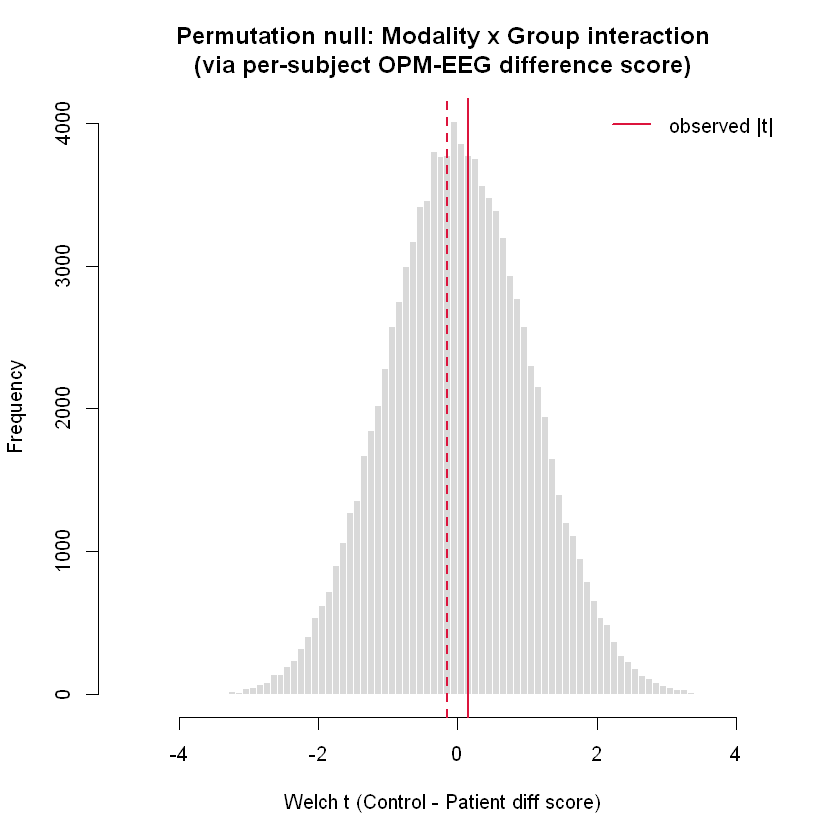

In [9]:
#####################################################
### Permutation test for the Modality x Group      ###
### interaction -- an assumption-free tiebreaker    ###
### between the ART and INT results                 ###
#####################################################

# Why this design collapses to a simple two-sample comparison:
# each subject (DatasetID) contributes exactly one EEG value and one
# OPM value (paired, within-subject, no missing modality), and
# SZ_EEG_INFO (Control/Patient) is a between-subject factor. For a
# within-subject factor with exactly 2 levels in a balanced design,
# testing the Modality:SZ_EEG_INFO interaction is algebraically
# IDENTICAL to testing whether the per-subject OPM-EEG difference
# score differs between Control and Patient -- this was verified
# against synthetic data before writing this: with an equal-variance
# t-test, t^2 matched the mixed model's interaction F to 6+ decimal
# places and the p-values were identical. That collapse means the
# whole repeated-measures structure can be reduced to one row per
# subject, which is both exact and fast to permute -- no need to
# refit a mixed model thousands of times.
#
# Test statistic: Welch's t (NOT the pooled/equal-variance t) on the
# diff score, comparing Control vs Patient. Welch's is deliberately
# used here instead of the algebraically-cleaner pooled t, because the
# whole motivation for this check is the concern that ART distorts
# results under unequal variances -- a plain permutation test using a
# pooled-variance statistic can still be sensitive to a Control/Patient
# variance mismatch when group sizes are unequal (the permutation
# version of the Behrens-Fisher problem). Welch's statistic guards
# against that on top of permutation already not needing a reference
# distribution's shape to be correct.

suppressMessages({
  library(dplyr)
  library(tidyr)
})

set.seed(1)  # reproducibility of the permutation draws -- change/report if you rerun

### -------------------------------------------------------------
### Step 1: collapse to one row per subject -- OPM-EEG difference
### -------------------------------------------------------------
subj_diff <- df_model %>%
  select(DatasetID, Modality, SZ_EEG_INFO, Value) %>%
  pivot_wider(names_from = Modality, values_from = Value) %>%
  mutate(diff = OPM - EEG)

# Sanity checks -- if either of these fails, the design isn't as
# balanced as assumed above and this shortcut isn't valid; you'd need
# the slower full-model-refit version instead (see bottom of file).
stopifnot(nrow(subj_diff) == length(unique(df_model$DatasetID)))
stopifnot(all(!is.na(subj_diff$diff)))
stopifnot(all(table(subj_diff$SZ_EEG_INFO) >= 2))  # need >=2 per group to permute meaningfully

cat(sprintf("n subjects: %d total (%s)\n", nrow(subj_diff),
            paste(names(table(subj_diff$SZ_EEG_INFO)), table(subj_diff$SZ_EEG_INFO),
                  sep = "=", collapse = ", ")))

### -------------------------------------------------------------
### Step 2: observed test statistic
### -------------------------------------------------------------
observed_test <- t.test(diff ~ SZ_EEG_INFO, data = subj_diff, var.equal = FALSE)
observed_t <- unname(observed_test$statistic)
cat(sprintf("Observed Welch t (Control vs Patient diff score) = %.3f\n", observed_t))

### -------------------------------------------------------------
### Step 3: permutation null -- shuffle group labels across
### subjects, recompute Welch's t, repeat many times
### -------------------------------------------------------------
n_perm <- 100000
perm_t <- numeric(n_perm)

group_vec <- subj_diff$SZ_EEG_INFO
diff_vec  <- subj_diff$diff

for (i in seq_len(n_perm)) {
  shuffled <- sample(group_vec)
  # split diff_vec by the shuffled labels and compute Welch's t directly
  # (faster than calling t.test() in a loop 100k times)
  x <- diff_vec[shuffled == levels(group_vec)[1]]
  y <- diff_vec[shuffled == levels(group_vec)[2]]
  nx <- length(x); ny <- length(y)
  vx <- var(x); vy <- var(y)
  se <- sqrt(vx / nx + vy / ny)
  perm_t[i] <- if (se > 0) (mean(x) - mean(y)) / se else 0
}

perm_p <- mean(abs(perm_t) >= abs(observed_t))
cat(sprintf("Permutation p-value (%d permutations, two-sided) = %.4f\n", n_perm, perm_p))

### 95% Monte Carlo CI on the permutation p-value itself (binomial),
### so you know how precisely n_perm pins this down
mc_se <- sqrt(perm_p * (1 - perm_p) / n_perm)
cat(sprintf("  (Monte Carlo 95%% CI on that p-value: %.4f - %.4f)\n",
            max(0, perm_p - 1.96 * mc_se), perm_p + 1.96 * mc_se))

### -------------------------------------------------------------
### Step 4: compare against ART and INT
### -------------------------------------------------------------
cat("\n--- Summary across all three methods ---\n")
cat("ART           : F(1,47) = 12.74, p < .001,  partial eta^2 = .213\n")
cat("INT + lmer    : F(1,47) = 3.321, p = .075,   partial eta^2 ~ .066\n")
cat(sprintf("Permutation   : Welch t = %.3f, p = %.4f  (no distributional assumptions)\n",
            observed_t, perm_p))

### -------------------------------------------------------------
### Step 5: histogram of the null distribution, useful for a
### supplementary figure showing the observed statistic against
### the empirical null
### -------------------------------------------------------------
hist(perm_t, breaks = 80,
     main = "Permutation null: Modality x Group interaction\n(via per-subject OPM-EEG difference score)",
     xlab = "Welch t (Control - Patient diff score)", col = "grey85", border = "white")
abline(v = observed_t, col = "#DC143C", lwd = 2)
abline(v = -observed_t, col = "#DC143C", lwd = 2, lty = 2)
legend("topright", legend = c("observed |t|"), col = "#DC143C", lwd = 2, bty = "n")

### -------------------------------------------------------------
### OPTIONAL / SLOWER alternative: full mixed-model refit per
### permutation. Only needed if your design stops being a clean
### balanced 2-level-within-factor case (e.g. you add CommonTrials
### back as a covariate, or the design becomes unbalanced/has
### missing modality data for some subjects) -- in that case the
### diff-score shortcut above is no longer exactly equivalent to
### the interaction F-test and you'd want this instead. Left here
### commented out because it's ~1000x slower (refits a mixed model
### every permutation) and wasn't needed for your current design.
# library(lme4); library(car)
# n_perm_slow <- 2000
# perm_F <- numeric(n_perm_slow)
# for (i in seq_len(n_perm_slow)) {
#   perm_df <- df_model
#   shuffled_lookup <- setNames(sample(group_vec), subj_diff$DatasetID)
#   perm_df$SZ_EEG_INFO <- shuffled_lookup[as.character(perm_df$DatasetID)]
#   m_perm <- lmer(Value ~ Modality * SZ_EEG_INFO + (1 | DatasetID), data = perm_df)
#   a_perm <- Anova(m_perm, type = 3, test.statistic = "F")
#   perm_F[i] <- a_perm["Modality:SZ_EEG_INFO", "F"]
# }
# observed_F <- 12.74  # or pull from your art_analysis.R / int_analysis.R run
# mean(perm_F >= observed_F)

Group within OPM: Welch t = 1.568, permutation p = 0.1254
Group within EEG: Welch t = 1.965, permutation p = 0.0529

--- Group contrast, permutation-based (planned family of 2, Holm-corrected) ---
 contrast  welch_t   p_raw  p_holm
      OPM 1.568127 0.12538 0.12538
      EEG 1.964829 0.05291 0.10582

--- For comparison: ART's art.con() results (logged) ---
Group within OPM (Ctrl - Patient): estimate = 21.31, p_holm = .016 -- significant
Group within EEG (Ctrl - Patient): estimate =  9.49, p_holm = .205 -- NOT significant


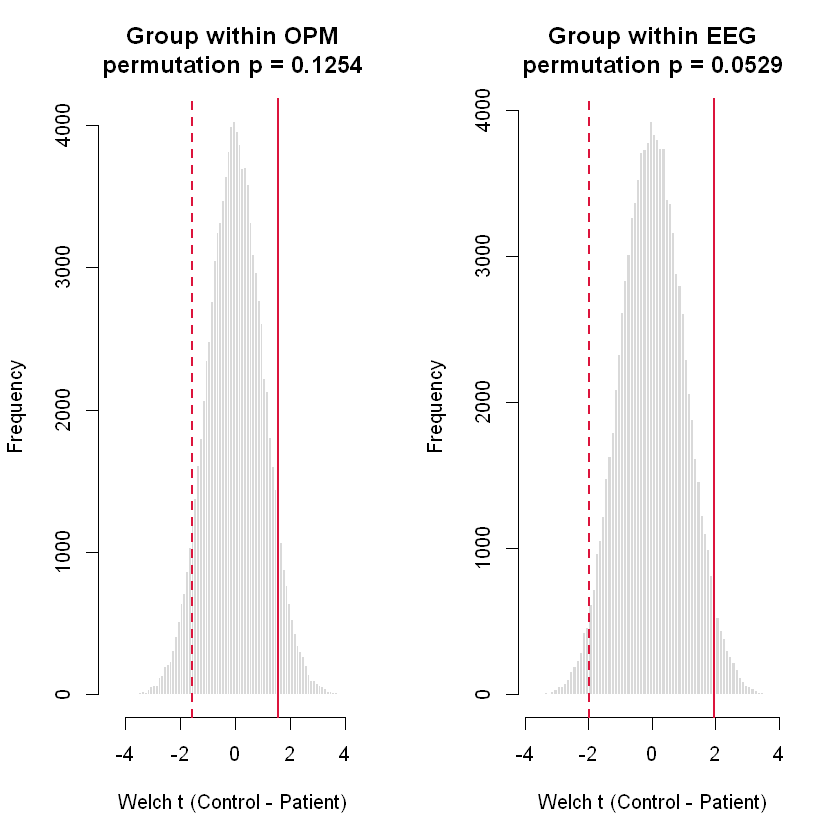

In [15]:
#####################################################
### Permutation tests for the two group contrasts   ###
### that carry your headline finding, tested         ###
### independently of the (collapsed) interaction:    ###
###   - Group within OPM  (Control vs Patient)        ###
###   - Group within EEG  (Control vs Patient)        ###
#####################################################

# Why these are tested separately rather than via the interaction:
# the omnibus Modality:SZ_EEG_INFO interaction did not survive the
# assumption-free permutation test (p = .88), which means you can no
# longer point to a significant interaction as license to claim
# "Group matters under OPM but not EEG, and that asymmetry is itself
# established." But "Group differs under OPM" and "Group differs
# under EEG" are each, on their own, ordinary two-independent-groups
# comparisons -- they don't need the interaction to be true to be
# individually meaningful. This script tests each one on its own
# terms, with the same zero-assumption permutation logic as before,
# so whatever survives here stands independent of what happened to
# the interaction.
#
# Test statistic: Welch's t (unequal-variance), same rationale as the
# interaction permutation test -- guards against a Control/Patient
# variance mismatch on top of permutation already not needing any
# reference distribution to be correct.
#
# Multiple comparisons: these two tests are treated as a planned
# family of 2 (mirroring how your ART follow-ups treated the 4
# theoretically-motivated contrasts as one family, not corrected
# against every possible contrast) -- Holm-corrected against each
# other, not against the OPM/EEG modality contrasts as well.

set.seed(1)

### -------------------------------------------------------------
### Step 0: build the two single-modality subsets. Each subject
### contributes exactly one row per modality, so subsetting by
### Modality collapses to one row per subject with a fixed group
### label -- straightforward independent-groups data.
### -------------------------------------------------------------
opm_df <- df_model[df_model$Modality == "OPM", c("DatasetID", "SZ_EEG_INFO", "Value")]
eeg_df <- df_model[df_model$Modality == "EEG", c("DatasetID", "SZ_EEG_INFO", "Value")]

stopifnot(nrow(opm_df) == length(unique(df_model$DatasetID)))
stopifnot(nrow(eeg_df) == length(unique(df_model$DatasetID)))

### -------------------------------------------------------------
### Reusable permutation routine for an independent two-group
### Welch's-t comparison
### -------------------------------------------------------------
permutation_test_indep <- function(value, group, n_perm = 100000) {
  observed_t <- unname(t.test(value ~ group, var.equal = FALSE)$statistic)

  lv <- levels(as.factor(group))
  perm_t <- numeric(n_perm)
  for (i in seq_len(n_perm)) {
    shuffled <- sample(group)
    x <- value[shuffled == lv[1]]
    y <- value[shuffled == lv[2]]
    se <- sqrt(var(x) / length(x) + var(y) / length(y))
    perm_t[i] <- if (se > 0) (mean(x) - mean(y)) / se else 0
  }

  perm_p <- mean(abs(perm_t) >= abs(observed_t))
  list(observed_t = observed_t, perm_p = perm_p, perm_t = perm_t, n_perm = n_perm)
}

### -------------------------------------------------------------
### Step 1: Group within OPM (Control vs Patient)
### -------------------------------------------------------------
res_opm <- permutation_test_indep(opm_df$Value, opm_df$SZ_EEG_INFO)
cat(sprintf("Group within OPM: Welch t = %.3f, permutation p = %.4f\n",
            res_opm$observed_t, res_opm$perm_p))

### -------------------------------------------------------------
### Step 2: Group within EEG (Control vs Patient)
### -------------------------------------------------------------
res_eeg <- permutation_test_indep(eeg_df$Value, eeg_df$SZ_EEG_INFO)
cat(sprintf("Group within EEG: Welch t = %.3f, permutation p = %.4f\n",
            res_eeg$observed_t, res_eeg$perm_p))

### -------------------------------------------------------------
### Step 3: Holm-correct across this 2-contrast planned family
### -------------------------------------------------------------
p_raw  <- c(OPM = res_opm$perm_p, EEG = res_eeg$perm_p)
p_holm <- p.adjust(p_raw, method = "holm")

cat("\n--- Group contrast, permutation-based (planned family of 2, Holm-corrected) ---\n")
print(data.frame(
  contrast = names(p_raw),
  welch_t  = c(res_opm$observed_t, res_eeg$observed_t),
  p_raw    = p_raw,
  p_holm   = p_holm
), row.names = FALSE)

### -------------------------------------------------------------
### Step 4: compare against what ART's follow-up contrasts claimed
### (section 5 of your stats log)
### -------------------------------------------------------------
cat("\n--- For comparison: ART's art.con() results (logged) ---\n")
cat("Group within OPM (Ctrl - Patient): estimate = 21.31, p_holm = .016 -- significant\n")
cat("Group within EEG (Ctrl - Patient): estimate =  9.49, p_holm = .205 -- NOT significant\n")

### -------------------------------------------------------------
### Step 5: diagnostic plots -- one null histogram per contrast
### -------------------------------------------------------------
par(mfrow = c(1, 2))
for (nm in c("OPM", "EEG")) {
  res <- if (nm == "OPM") res_opm else res_eeg
  hist(res$perm_t, breaks = 80, col = "grey85", border = "white",
       main = sprintf("Group within %s\npermutation p = %.4f", nm, res$perm_p),
       xlab = "Welch t (Control - Patient)")
  abline(v = res$observed_t, col = "#DC143C", lwd = 2)
  abline(v = -res$observed_t, col = "#DC143C", lwd = 2, lty = 2)
}
par(mfrow = c(1, 1))